In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()
model = ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite',
    google_api_key=os.getenv('GEMINI_API_KEY')
)

In [4]:
class Blog(TypedDict):

    title : str
    outline : str
    content : str
    evaluate : int

In [5]:
def create_outline(state: Blog) -> Blog:

    title = state['title']
    prompt=f'generate a detailed outline on the topic - {title}'
    outline=model.invoke(prompt).content

    state['outline']=outline

    return state

In [6]:
def create_content(state : Blog) -> Blog:

    title=state['title']
    outline=state['outline']
    prompt=f'create a detailed blog on the topic-{title} along with given outline-{outline}'

    content=model.invoke(prompt).content

    state['content']=content

    return state

In [7]:
def evaluate(state : Blog) -> Blog:

    title=state['title']
    outline=state['outline']
    content=state['content']

    prompt=f'based on given title->{title} and outline->{outline} and content->{content} evaluate the content on the scale of 1 to 10'

    evaluate=model.invoke(prompt).content

    state['evaluate']=evaluate

    return state

In [8]:
graph = StateGraph(Blog)

graph.add_node('create_outline',create_outline)
graph.add_node('create_content',create_content)
graph.add_node('evaluate',evaluate)

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_content')
graph.add_edge('create_content','evaluate')
graph.add_edge('evaluate',END)

workflow=graph.compile()

In [9]:
initial_state={'title':'corona virus'}

final_state=workflow.invoke(initial_state)



Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [10]:
print(final_state['outline'])
print(final_state['content'])


[{'type': 'text', 'text': 'This outline provides a comprehensive overview of COVID-19, covering its origins, biological nature, societal impact, and the path toward recovery.\n\n---\n\n### **I. Introduction**\n*   **Definition:** What is COVID-19? (Coronavirus Disease 2019).\n*   **The Virus:** Identification of SARS-CoV-2 (Severe Acute Respiratory Syndrome Coronavirus 2).\n*   **Historical Context:** Emergence in late 2019 and declaration of a global pandemic by the WHO in March 2020.\n*   **Significance:** Unprecedented global health, economic, and social crisis.\n\n### **II. Virology and Biology**\n*   **Structure of the Virus:** Spike proteins, RNA genome, and the envelope.\n*   **Mechanism of Infection:** How SARS-CoV-2 enters human cells (ACE2 receptors).\n*   **Variants and Mutations:**\n    *   Why viruses mutate (Alpha, Delta, Omicron, etc.).\n    *   Implications of mutations on transmissibility and immune evasion.\n\n### **III. Epidemiology and Transmission**\n*   **Modes of

In [11]:
print(final_state['evaluate'])

[{'type': 'text', 'text': 'To evaluate the content provided, I have assessed it based on **structure, technical accuracy, clarity, and adherence to the outline**.\n\n### **Overall Rating: 9.5/10**\n\n---\n\n### **Detailed Evaluation**\n\n#### **1. Structural Integrity & Flow (10/10)**\nThe content follows the provided outline perfectly. Each section corresponds directly to the Roman numerals and sub-bullet points, ensuring a logical progression from the scientific origins of the virus to its societal impacts and future outlook. The transition between sections is smooth, providing a cohesive narrative rather than a list of facts.\n\n#### **2. Quality of Information (9/10)**\nThe content is high-quality, professional, and captures the nuance of complex topics (like the "infodemic" or the "cytokine storm") without becoming overly bogged down in jargon. It successfully synthesizes large amounts of data into an accessible format for a general audience. \n\n*   *Minor observation:* The secti

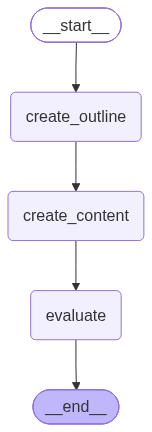

In [13]:
# display workflow
workflow